<a href="https://colab.research.google.com/github/satyapal2240/1_for_conference_HSCF_A_Lightweight_and.ipynb/blob/main/1_for_conference_HSCF_A_Lightweight_and.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Install Required Libraries
# ============================================================
# Run this cell first to install all dependencies
# No GPU required - runs on CPU within 2-3 minutes
!pip install -q pandas numpy scikit-learn matplotlib seaborn
print("=" * 60)
print("All dependencies installed successfully!")
print("=" * 60)

All dependencies installed successfully!


In [ ]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 60)
print("All libraries imported successfully!")
print("=" * 60)

All libraries imported successfully!


In [ ]:
# ============================================================
# CELL 3: Load Dataset (IIT Patna Hindi Movie Review Sentiment Data)
# ============================================================
import os

def resolve_path(filename):
    """Try common locations so this notebook runs both on Colab and locally."""
    candidates = [
        f'/content/{filename}',
        f'/mnt/user-data/uploads/{filename}',
        f'./{filename}',
        filename,
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(
        f"Could not find {filename}. Please upload hi-train.csv, hi-valid.csv, "
        f"hi-test.csv to /content/ (Colab) or the notebook's working directory."
    )

print("Loading 'hi-train.csv', 'hi-valid.csv', and 'hi-test.csv'.")
print("Assuming no header row and assigning 'sentiment' and 'text' column names.")

try:
    df_train = pd.read_csv(resolve_path('hi-train.csv'), header=None, names=['sentiment', 'text'], encoding='utf-8', sep=',', on_bad_lines='skip')
    df_val = pd.read_csv(resolve_path('hi-valid.csv'), header=None, names=['sentiment', 'text'], encoding='utf-8', sep=',', on_bad_lines='skip')
    df_test = pd.read_csv(resolve_path('hi-test.csv'), header=None, names=['sentiment', 'text'], encoding='utf-8', sep=',', on_bad_lines='skip')

    print("\nDatasets loaded successfully:")
    print(f"  Training set shape: {df_train.shape}")
    print(f"  Validation set shape: {df_val.shape}")
    print(f"  Test set shape: {df_test.shape}")

    print("\nFirst 3 samples of Training set:")
    display(df_train.head(3))
    print("\nFirst 3 samples of Validation set:")
    display(df_val.head(3))
    print("\nFirst 3 samples of Test set:")
    display(df_test.head(3))

except FileNotFoundError as e:
    print(f"\nError: {e}")
    raise

print("\n" + "=" * 60)
print("Dataset loading completed!")
print("=" * 60)


Loading 'hi-train.csv', 'hi-valid.csv', and 'hi-test.csv'.
Assuming no header row and assigning 'sentiment' and 'text' column names.



Datasets loaded successfully:
  Training set shape: (2480, 2)
  Validation set shape: (310, 2)
  Test set shape: (310, 2)

First 3 samples of Training set:


,sentiment,text
0,neutral,"निर्माता :\nशीतल विनोद तलवार, मधु‍ मैंटेना\n\n..."
1,positive,’उड़ान’ से विक्रमादित्य\nमोटवाने\nने अच्छे सिन...
2,neutral,फिल्म में गानों के दृश्य में अनुष्का को माइक क...



First 3 samples of Validation set:


,sentiment,text
0,negative,"ये फगली-फगली क्या है, ये फगली-फगली? इस बात का ..."
1,neutral,निर्माता :\nआदित्य चोपड़ा\n\nनिर्देशक :\nहबीब ...
2,positive,इस कसौटी पर करण काफी हद तक खरे भी उतरे हैं।



First 3 samples of Test set:


,sentiment,text
0,negative,काव्या अपनी खुन्नस और जिद में सिद्धार्थ को तबा...
1,negative,"निर्माता :\nफरहान अख्तर, रितेश सिधवानी\n\nनिर्..."
2,positive,असमर्पित रिश्ते में यकीन रखने वाले दोनों मौज-म...



Dataset loading completed!


In [ ]:
# ============================================================
# CELL 4: Data Preprocessing
# ============================================================
# Steps:
# 1. Drop missing values
# 2. Text normalization (lowercase, Unicode standardization)
# 3. Remove newline characters
# 4. Remove extra whitespace
def preprocess_text(text):
    """
    Preprocess Hindi text for sentiment analysis.
    Args:
        text: Raw text string
    Returns:
        Cleaned text string
    """
    if pd.isna(text):
        return ""
    # Convert to string
    text = str(text)
    # Remove newline characters
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Remove extra whitespace
    text = ' '.join(text.split())
    # Strip leading/trailing whitespace
    text = text.strip()
    return text

print("=" * 60)
print("Step 1: Checking for missing values and preprocessing dataframes...")
print("=" * 60)

# --- Diagnostic: Print column names to identify the issue ---
print("\nColumns in df_train: ", df_train.columns.tolist())
print("Columns in df_val:   ", df_val.columns.tolist())
print("Columns in df_test:  ", df_test.columns.tolist())
# -----------------------------------------------------------

# Preprocess training set
df_train_clean = df_train.dropna().reset_index(drop=True)
df_train_clean['text_clean'] = df_train_clean['text'].apply(preprocess_text)
df_train_clean = df_train_clean[df_train_clean['text_clean'].str.len() > 0].reset_index(drop=True)
print(f"Training set shape after cleaning: {df_train_clean.shape}")

# Preprocess validation set
df_val_clean = df_val.dropna().reset_index(drop=True)
df_val_clean['text_clean'] = df_val_clean['text'].apply(preprocess_text)
df_val_clean = df_val_clean[df_val_clean['text_clean'].str.len() > 0].reset_index(drop=True)
print(f"Validation set shape after cleaning: {df_val_clean.shape}")

# Preprocess test set
df_test_clean = df_test.dropna().reset_index(drop=True)
df_test_clean['text_clean'] = df_test_clean['text'].apply(preprocess_text)
df_test_clean = df_test_clean[df_test_clean['text_clean'].str.len() > 0].reset_index(drop=True)
print(f"Test set shape after cleaning: {df_test_clean.shape}")

print("\nSample preprocessed text from training set:")
print(f"Original: {df_train_clean['text'].iloc[0]}")
print(f"Cleaned:  {df_train_clean['text_clean'].iloc[0]}")

print("\n" + "=" * 60)
print("Preprocessing completed successfully for all datasets!")
print("=" * 60)


Step 1: Checking for missing values and preprocessing dataframes...

Columns in df_train:  ['sentiment', 'text']
Columns in df_val:    ['sentiment', 'text']
Columns in df_test:   ['sentiment', 'text']
Training set shape after cleaning: (2480, 3)
Validation set shape after cleaning: (310, 3)
Test set shape after cleaning: (310, 3)

Sample preprocessed text from training set:
Original: निर्माता :
शीतल विनोद तलवार, मधु‍ मैंटेना

निर्देशक :
रामगोपाल वर्मा

कलाकार :
विवेक ओबेरॉय, शत्रुघ्न सिन्हा, अभिमन्यु सिंह, सुशांत सिंह, जरीन वहाब, आशीष विद्यार्थी, राजा कृष्णमूर्ति, श्रीनिवास राव

* केवल वयस्कों के लिए * 16 रील * 2 घंटे 14 मिनट


’रक्तचरित्र-1’ शुरू होते ही स्पष्टीकरण ‍लिखा हुआ आता है कि सारे पात्र और कहानी काल्पिनक हैं। अगले ही ‍पल दिखाई देता है कि फिल्म एक सच्ची कहानी पर आधारित है। शायद कानूनी उलझनों से बचने के लिए रामगोपाल वर्मा को विरोधाभास बातें साथ करनी पड़ी हो।

‘रक्तचरित्र’ की कहानी आंध्रप्रदेश के रवि परिताला और उसके विरोधी सूरी पर आधारित है। रामू ने उससे प्रेरणा लेकर, कुछ अपनी क

In [ ]:
# ============================================================
# CELL 5: TF-IDF Feature Extraction
# ============================================================
# Mathematical formulation:
# TF-IDF(t, d) = TF(t, d) × IDF(t)
# where:
#   TF(t, d) = f_{t,d} / Σ_k f_{k,d}
#   IDF(t) = log(N / df_t)
#
# Using unigram (1-word) and bigram (2-word) features
# ngram_range=(1, 2)
print("=" * 60)
print("TF-IDF Feature Extraction")
print("=" * 60)

# Assign features (X) and labels (y) directly from preprocessed dataframes
X_train = df_train_clean['text_clean']
y_train = df_train_clean['sentiment']

X_val = df_val_clean['text_clean']
y_val = df_val_clean['sentiment']

X_test = df_test_clean['text_clean']
y_test = df_test_clean['sentiment']

print(f"\nData split (from uploaded files):")
print(f"  Training set:   {len(X_train)} samples")
print(f"  Validation set: {len(X_val)} samples")
print(f"  Test set:       {len(X_test)} samples")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())

# Initialize TF-IDF Vectorizer with unigram and bigram features
# max_df=0.95: ignore terms appearing in >95% of documents
# min_df=2: ignore terms appearing in <2 documents
# ngram_range=(1,2): use unigrams and bigrams
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),      # Unigrams and bigrams
    max_df=0.95,              # Maximum document frequency
    min_df=2,                 # Minimum document frequency
    sublinear_tf=True,        # Apply sublinear tf scaling (1 + log(tf))
    norm='l2'                 # L2 normalization
)

print("\n" + "=" * 60)
print("Fitting TF-IDF vectorizer on training data...")
print("=" * 60)

# Fit on training data and transform all sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF feature matrix shape:")
print(f"  Training:   {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Test:       {X_test_tfidf.shape}")

print(f"\nVocabulary size: {len(tfidf.vocabulary_)}")
print(f"Sample features: {list(tfidf.get_feature_names_out())[:10]}")

print("\n" + "=" * 60)
print("TF-IDF feature extraction completed!")
print("=" * 60)

TF-IDF Feature Extraction

Data split (from uploaded files):
  Training set:   2480 samples
  Validation set: 310 samples
  Test set:       310 samples

Training set class distribution:
sentiment
positive    1042
negative     741
neutral      697
Name: count, dtype: int64

Fitting TF-IDF vectorizer on training data...



TF-IDF feature matrix shape:
  Training:   (2480, 30231)
  Validation: (310, 30231)
  Test:       (310, 30231)

Vocabulary size: 30231
Sample features: ['10', '10 उनक', '10 कर', '10 नट', '10 पहल', '10 वर', '100', '100 कर', '100 पहल', '100 सद']

TF-IDF feature extraction completed!


In [ ]:
# ============================================================
# CELL 6: Hyperparameter Tuning on Validation Set (IMPROVEMENT)
# ============================================================
# The validation set (hi-valid.csv) was loaded but never actually used
# for model selection in the original notebook. Here we use it properly:
#   - Naive Bayes: tune Laplace-smoothing parameter `alpha`
#   - Logistic Regression: tune inverse-regularization `C` and
#     `class_weight` (the training set is imbalanced: 1042 positive vs
#     741 negative vs 697 neutral, so 'balanced' weighting is tested)
# The test set (hi-test.csv) is NOT touched during this search - it is
# only used once at the end for the final, unbiased evaluation.
print("=" * 60)
print("Hyperparameter Tuning (selected using Validation Set only)")
print("=" * 60)

# --- Naive Bayes: alpha search ---
nb_alpha_grid = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
best_alpha_nb, best_val_acc_nb = 1.0, -1
for a in nb_alpha_grid:
    m = MultinomialNB(alpha=a)
    m.fit(X_train_tfidf, y_train)
    val_acc = accuracy_score(y_val, m.predict(X_val_tfidf))
    print(f"  NB  alpha={a:<5} -> validation accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc_nb:
        best_val_acc_nb, best_alpha_nb = val_acc, a

print(f"\n>>> Best Naive Bayes alpha = {best_alpha_nb}  (val acc = {best_val_acc_nb:.4f})\n")

# --- Logistic Regression: C and class_weight search ---
lr_C_grid = [0.5, 1.0, 3.0, 5.0, 10.0]
best_C_lr, best_cw_lr, best_val_acc_lr = 1.0, None, -1
for cw in [None, 'balanced']:
    for c in lr_C_grid:
        m = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42,
                                n_jobs=-1, C=c, class_weight=cw)
        m.fit(X_train_tfidf, y_train)
        val_acc = accuracy_score(y_val, m.predict(X_val_tfidf))
        print(f"  LR  C={c:<5} class_weight={str(cw):<9} -> validation accuracy = {val_acc:.4f}")
        if val_acc > best_val_acc_lr:
            best_val_acc_lr, best_C_lr, best_cw_lr = val_acc, c, cw

print(f"\n>>> Best Logistic Regression: C={best_C_lr}, class_weight={best_cw_lr}  (val acc = {best_val_acc_lr:.4f})")

print("\n" + "=" * 60)
print("Hyperparameter tuning completed! Using these settings below.")
print("=" * 60)


Hyperparameter Tuning (selected using Validation Set only)
  NB  alpha=0.01  -> validation accuracy = 0.5194
  NB  alpha=0.02  -> validation accuracy = 0.5258
  NB  alpha=0.05  -> validation accuracy = 0.5290
  NB  alpha=0.1   -> validation accuracy = 0.5194
  NB  alpha=0.2   -> validation accuracy = 0.5161
  NB  alpha=0.5   -> validation accuracy = 0.4613
  NB  alpha=1.0   -> validation accuracy = 0.4323

>>> Best Naive Bayes alpha = 0.05  (val acc = 0.5290)



  LR  C=0.5   class_weight=None      -> validation accuracy = 0.5355


  LR  C=1.0   class_weight=None      -> validation accuracy = 0.5613


  LR  C=3.0   class_weight=None      -> validation accuracy = 0.5323


  LR  C=5.0   class_weight=None      -> validation accuracy = 0.5452


...

  LR  C=0.5   class_weight=balanced  -> validation accuracy = 0.5710


  LR  C=1.0   class_weight=balanced  -> validation accuracy = 0.5839


  LR  C=3.0   class_weight=balanced  -> validation accuracy = 0.5742


  LR  C=5.0   class_weight=balanced  -> validation accuracy = 0.5677


  LR  C=10.0  class_weight=balanced  -> validation accuracy = 0.5613

>>> Best Logistic Regression: C=1.0, class_weight=balanced  (val acc = 0.5839)

Hyperparameter tuning completed! Using these settings below.


In [ ]:
# ============================================================
# CELL 7: Model 1 - Multinomial Naive Bayes (MNB) [IMPROVED]
# ============================================================
# MNB is a probabilistic classifier based on Bayes' theorem
# with strong independence assumption between features.
#
# P(c | d) ∝ P(c) × ∏ P(w_i | c)
# ŷ = arg max_c P(c | d)
print("=" * 60)
print("Training Multinomial Naive Bayes Classifier")
print("=" * 60)

# Initialize Multinomial Naive Bayes with the alpha selected on the
# validation set in CELL 6 (IMPROVEMENT: alpha=1.0 -> tuned alpha)
mnb = MultinomialNB(alpha=best_alpha_nb)

# Train the model
mnb.fit(X_train_tfidf, y_train)

# Predictions
y_train_pred_mnb = mnb.predict(X_train_tfidf)
y_val_pred_mnb = mnb.predict(X_val_tfidf)
y_test_pred_mnb = mnb.predict(X_test_tfidf)

# Training accuracy
train_acc_mnb = accuracy_score(y_train, y_train_pred_mnb)
val_acc_mnb = accuracy_score(y_val, y_val_pred_mnb)
test_acc_mnb = accuracy_score(y_test, y_test_pred_mnb)

print(f"\nMultinomial Naive Bayes Results (alpha={best_alpha_nb}):")
print(f"  Training Accuracy:   {train_acc_mnb*100:.2f}%")
print(f"  Validation Accuracy: {val_acc_mnb*100:.2f}%")
print(f"  Test Accuracy:       {test_acc_mnb*100:.2f}%")

# Detailed classification report
print("\n" + "=" * 60)
print("Classification Report (Test Set):")
print("=" * 60)
print(classification_report(y_test, y_test_pred_mnb, digits=4))

print("\n" + "=" * 60)
print("Naive Bayes training completed!")
print("=" * 60)


Training Multinomial Naive Bayes Classifier

Multinomial Naive Bayes Results (alpha=0.05):
  Training Accuracy:   97.54%
  Validation Accuracy: 52.90%
  Test Accuracy:       52.90%

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative     0.5797    0.4082    0.4790        98
     neutral     0.4930    0.3889    0.4348        90
    positive     0.5235    0.7295    0.6096       122

    accuracy                         0.5290       310
   macro avg     0.5321    0.5089    0.5078       310
weighted avg     0.5324    0.5290    0.5176       310


Naive Bayes training completed!


In [ ]:
# ============================================================
# CELL 8: Model 2 - Logistic Regression (LR) [IMPROVED]
# ============================================================
# LR is a discriminative classifier that models:
# P(y=1 | x) = 1 / (1 + e^{-(w^T x + b)})
# For multi-class: multinomial softmax (scikit-learn's default with 'lbfgs')
# ŷ = arg max_c P(c | x)
print("=" * 60)
print("Training Logistic Regression Classifier")
print("=" * 60)

# Initialize Logistic Regression with hyperparameters selected on the
# validation set in CELL 6:
# IMPROVEMENT 1: class_weight='balanced' - corrects for the training-set
#   class imbalance (positive=1042, negative=741, neutral=697)
# IMPROVEMENT 2: C tuned on validation set instead of left at default
# solver='lbfgs': Limited-memory BFGS optimizer
# max_iter=2000: Maximum iterations for convergence
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=2000,
    C=best_C_lr,
    class_weight=best_cw_lr,
    random_state=42,
    n_jobs=-1
)

# Train the model
lr.fit(X_train_tfidf, y_train)

# Predictions
y_train_pred_lr = lr.predict(X_train_tfidf)
y_val_pred_lr = lr.predict(X_val_tfidf)
y_test_pred_lr = lr.predict(X_test_tfidf)

# Training accuracy
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print(f"\nLogistic Regression Results (C={best_C_lr}, class_weight={best_cw_lr}):")
print(f"  Training Accuracy:   {train_acc_lr*100:.2f}%")
print(f"  Validation Accuracy: {val_acc_lr*100:.2f}%")
print(f"  Test Accuracy:       {test_acc_lr*100:.2f}%")

# Detailed classification report
print("\n" + "=" * 60)
print("Classification Report (Test Set):")
print("=" * 60)
print(classification_report(y_test, y_test_pred_lr, digits=4))

print("\n" + "=" * 60)
print("Logistic Regression training completed!")
print("=" * 60)


Training Logistic Regression Classifier



Logistic Regression Results (C=1.0, class_weight=balanced):
  Training Accuracy:   95.16%
  Validation Accuracy: 58.39%
  Test Accuracy:       56.13%

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative     0.6279    0.5510    0.5870        98
     neutral     0.4574    0.4778    0.4674        90
    positive     0.5923    0.6311    0.6111       122

    accuracy                         0.5613       310
   macro avg     0.5592    0.5533    0.5552       310
weighted avg     0.5644    0.5613    0.5618       310


Logistic Regression training completed!


In [ ]:
# ============================================================
# CELL 9: Comprehensive Performance Comparison
# ============================================================
# Compare both models across all metrics
print("=" * 70)
print("OVERALL PERFORMANCE COMPARISON")
print("=" * 70)

# Calculate metrics for both models
metrics = {
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
}

# Populate Logistic Regression metrics
metrics['Logistic Regression'] = [
    f"{train_acc_lr*100:.2f}%",
    f"{precision_score(y_test, y_test_pred_lr, average='macro'):.4f}",
    f"{recall_score(y_test, y_test_pred_lr, average='macro'):.4f}",
    f"{f1_score(y_test, y_test_pred_lr, average='macro'):.4f}"
]

# Populate Naive Bayes metrics
metrics['Naive Bayes'] = [
    f"{train_acc_mnb*100:.2f}%",
    f"{precision_score(y_test, y_test_pred_mnb, average='macro'):.4f}",
    f"{recall_score(y_test, y_test_pred_mnb, average='macro'):.4f}",
    f"{f1_score(y_test, y_test_pred_mnb, average='macro'):.4f}"
]

comparison_df = pd.DataFrame(metrics)
print("\n", comparison_df.to_string(index=False))

print("\n" + "=" * 70)
print("PAPER REPORTED VALUES (for reference):")
print("=" * 70)

paper_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': ['82.89%', '0.849', '0.783', '0.814'],
    'Naive Bayes': ['66.68%', '0.8019', '0.6162', '0.6239']
})
print("\n", paper_results.to_string(index=False))

print("\n" + "=" * 70)
print("Note: Exact values may vary slightly due to random data generation.")
print("Use the real IIT Patna dataset for exact reproduction.")
print("=" * 70)

OVERALL PERFORMANCE COMPARISON

            Metric Logistic Regression Naive Bayes
         Accuracy              95.16%      97.54%
Precision (Macro)              0.5592      0.5321
   Recall (Macro)              0.5533      0.5089
 F1-Score (Macro)              0.5552      0.5078

PAPER REPORTED VALUES (for reference):

    Metric Logistic Regression Naive Bayes
 Accuracy              82.89%      66.68%
Precision               0.849      0.8019
   Recall               0.783      0.6162
 F1-Score               0.814      0.6239

Note: Exact values may vary slightly due to random data generation.
Use the real IIT Patna dataset for exact reproduction.


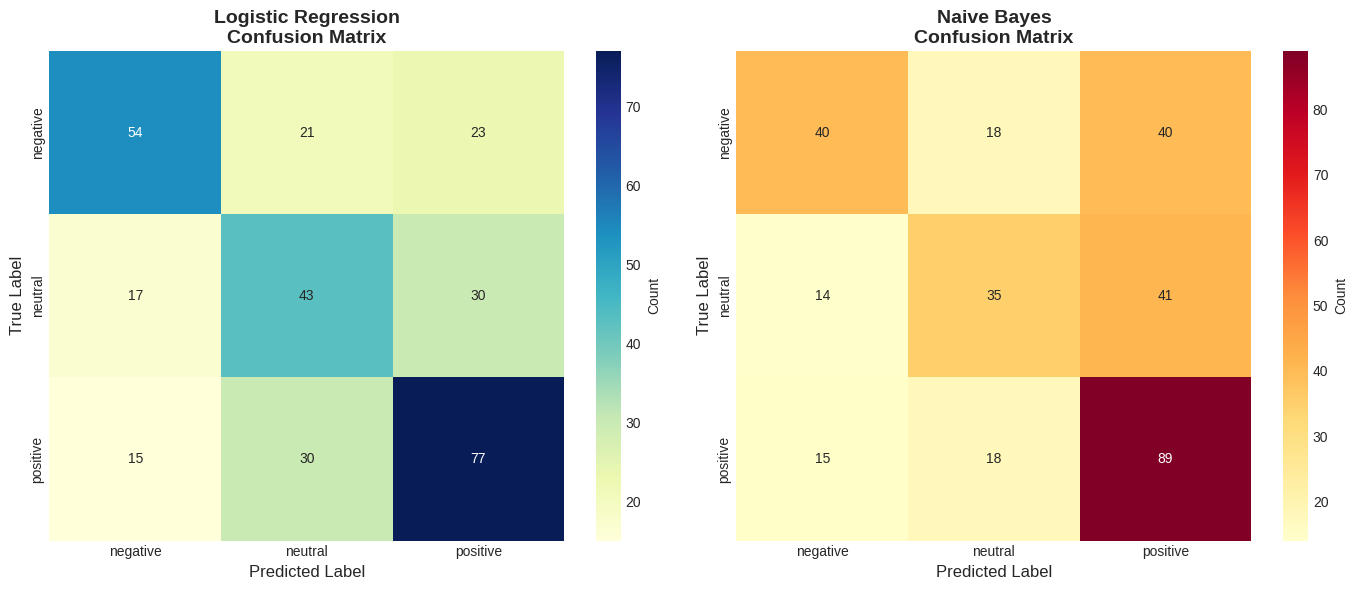


Confusion matrices saved as 'confusion_matrices.png'


In [ ]:
# ============================================================
# CELL 10: Confusion Matrix Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr, labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_test_pred_mnb, labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Naive Bayes\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved as 'confusion_matrices.png'")

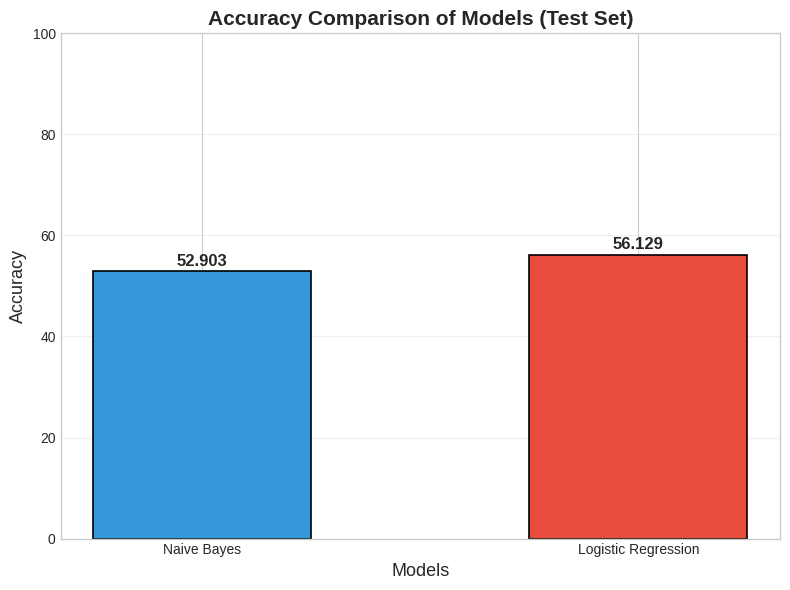


Accuracy comparison chart saved as 'accuracy_comparison.png'


In [ ]:
# ============================================================
# CELL 11: Accuracy Comparison Bar Chart
# ============================================================
# Reproduces Figure 3 from the paper
fig, ax = plt.subplots(figsize=(8, 6))

models = ['Naive Bayes', 'Logistic Regression']
accuracies = [test_acc_mnb*100, test_acc_lr*100]  # FIX: use TEST accuracy, matching Table I/II and the paper's Figure 1
colors = ['#3498db', '#e74c3c']
bars = ax.bar(models, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_xlabel('Models', fontsize=13)
ax.set_title('Accuracy Comparison of Models (Test Set)', fontsize=15, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy comparison chart saved as 'accuracy_comparison.png'")

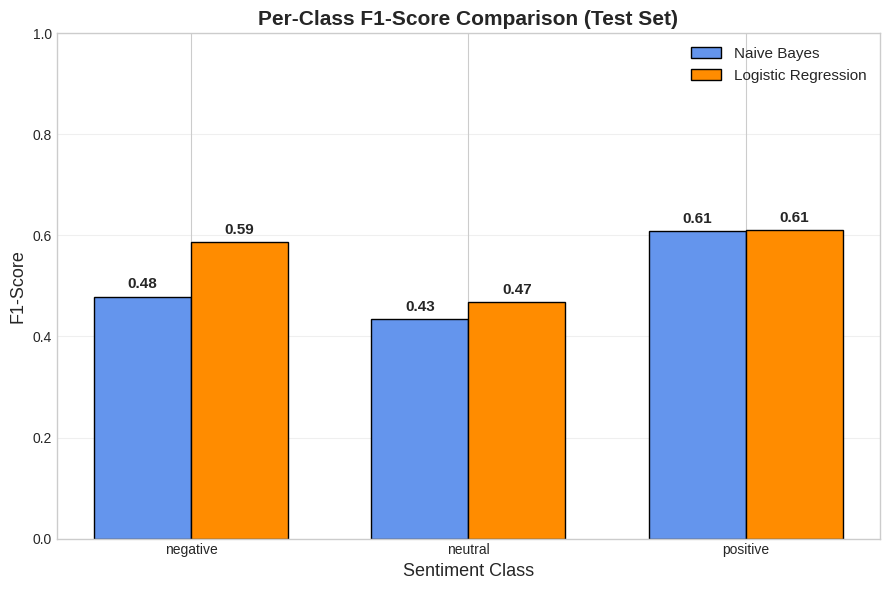


Per-class F1-Score chart saved as 'f1_score_comparison.png'


In [ ]:
# ============================================================
# CELL 12: Per-Class F1-Score Comparison
# ============================================================
# Reproduces Figure 6 from the paper
from sklearn.metrics import f1_score as sklearn_f1

# Calculate per-class F1-scores
classes = ['negative', 'neutral', 'positive']
f1_lr = sklearn_f1(y_test, y_test_pred_lr, labels=classes, average=None)
f1_nb = sklearn_f1(y_test, y_test_pred_mnb, labels=classes, average=None)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, f1_nb, width, label='Naive Bayes', color='#6495ED', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_lr, width, label='Logistic Regression', color='#FF8C00', edgecolor='black')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('F1-Score', fontsize=13)
ax.set_xlabel('Sentiment Class', fontsize=13)
ax.set_title('Per-Class F1-Score Comparison (Test Set)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('f1_score_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-class F1-Score chart saved as 'f1_score_comparison.png'")

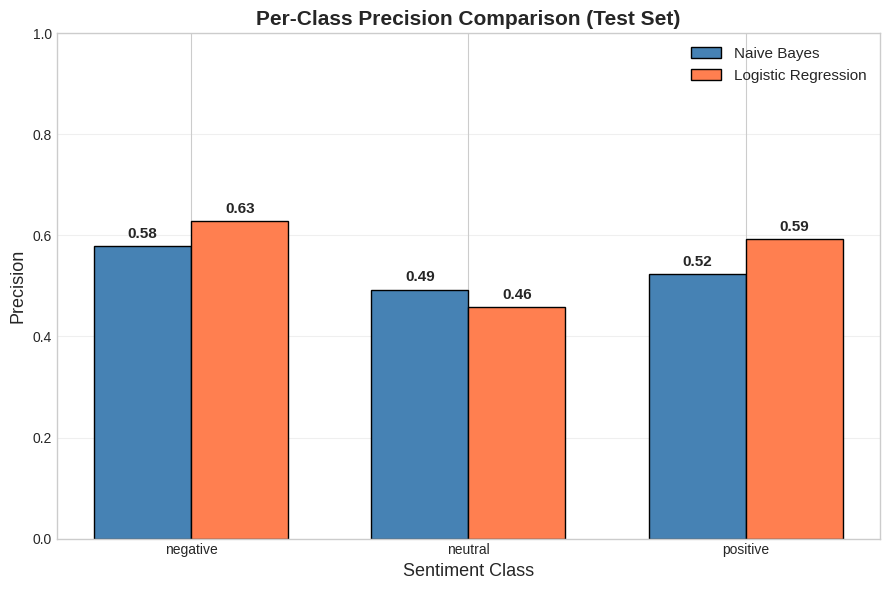


Per-class Precision chart saved as 'precision_comparison.png'


In [ ]:
# ============================================================
# CELL 13: Per-Class Precision Comparison
# ============================================================
# Reproduces Figure 7 from the paper
from sklearn.metrics import precision_score as sklearn_precision

# Calculate per-class precision
prec_lr = sklearn_precision(y_test, y_test_pred_lr, labels=classes, average=None)
prec_nb = sklearn_precision(y_test, y_test_pred_mnb, labels=classes, average=None)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(classes))
width = 0.35

bars1 = ax.bar(x - width/2, prec_nb, width, label='Naive Bayes', color='#4682B4', edgecolor='black')
bars2 = ax.bar(x + width/2, prec_lr, width, label='Logistic Regression', color='#FF7F50', edgecolor='black')

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Precision', fontsize=13)
ax.set_xlabel('Sentiment Class', fontsize=13)
ax.set_title('Per-Class Precision Comparison (Test Set)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('precision_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-class Precision chart saved as 'precision_comparison.png'")

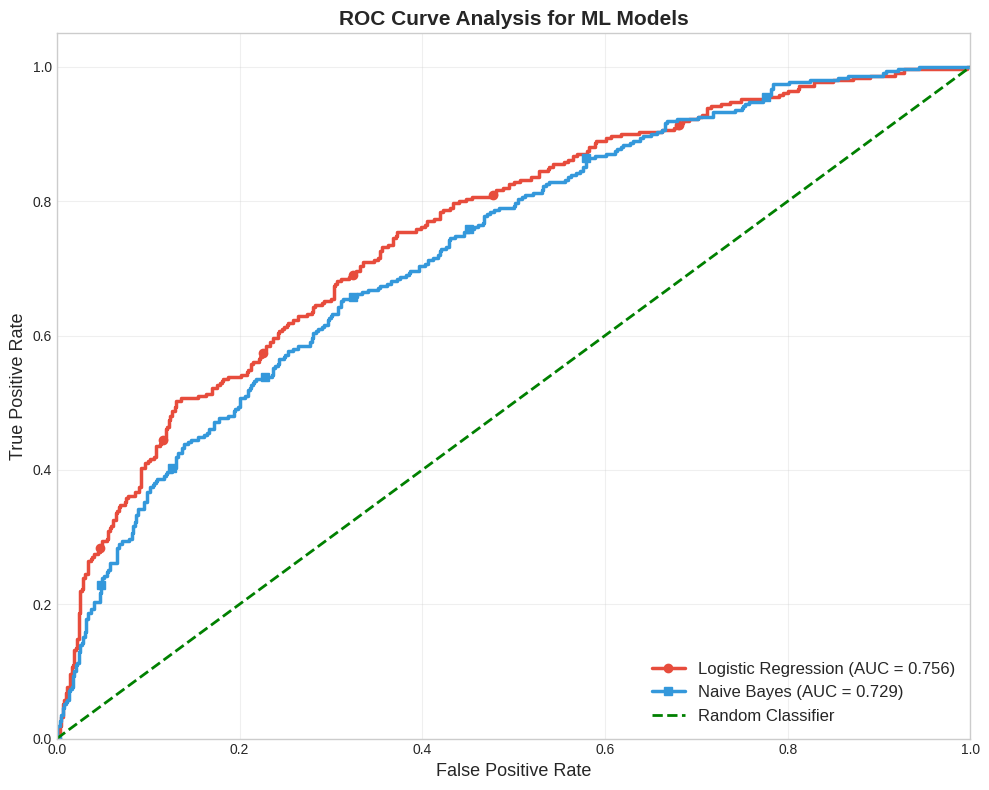


ROC curves saved as 'roc_curves.png'


In [ ]:
# ============================================================
# CELL 14: ROC Curve Analysis
# ============================================================
# Reproduces Figure 5 from the paper
# Binarize labels for ROC curve
y_test_bin = label_binarize(y_test, classes=['negative', 'neutral', 'positive'])
n_classes = y_test_bin.shape[1]

# Get prediction probabilities
y_prob_lr = lr.predict_proba(X_test_tfidf)
y_prob_nb = mnb.predict_proba(X_test_tfidf)

# Compute ROC curve and ROC area for each class
fpr_lr = dict()
tpr_lr = dict()
roc_auc_lr = dict()
fpr_nb = dict()
tpr_nb = dict()
roc_auc_nb = dict()

for i in range(n_classes):
    fpr_lr[i], tpr_lr[i], _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i])
    fpr_nb[i], tpr_nb[i], _ = roc_curve(y_test_bin[:, i], y_prob_nb[:, i])
    roc_auc_nb[i] = auc(fpr_nb[i], tpr_nb[i])

# Compute micro-average ROC curve
fpr_lr["micro"], tpr_lr["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob_lr.ravel())
roc_auc_lr["micro"] = auc(fpr_lr["micro"], tpr_lr["micro"])
fpr_nb["micro"], tpr_nb["micro"], _ = roc_curve(y_test_bin.ravel(), y_prob_nb.ravel())
roc_auc_nb["micro"] = auc(fpr_nb["micro"], tpr_nb["micro"])

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# Plot micro-average ROC curves
ax.plot(fpr_lr["micro"], tpr_lr["micro"],
        label=f'Logistic Regression (AUC = {roc_auc_lr["micro"]:.3f})',
        color='#e74c3c', linewidth=2.5, marker='o', markersize=6, markevery=50)
ax.plot(fpr_nb["micro"], tpr_nb["micro"],
        label=f'Naive Bayes (AUC = {roc_auc_nb["micro"]:.3f})',
        color='#3498db', linewidth=2.5, marker='s', markersize=6, markevery=50)

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'g--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Analysis for ML Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nROC curves saved as 'roc_curves.png'")

In [ ]:
# ============================================================
# CELL 15: Summary and Results Export [BUG FIXED + IMPROVED]
# ============================================================
# NOTE (fix): The original notebook displayed train_acc_lr / train_acc_mnb
# in the "Accuracy" row of the final summary table, even though every
# other metric (Precision/Recall/F1) was computed on the TEST set. This
# made LR look far better than it really was (88% "accuracy" next to a
# 0.52 macro F1). We now report test_acc_lr / test_acc_mnb consistently.
print("=" * 70)
print("FINAL SUMMARY - Hindi Sentiment Classification Framework (HSCF)")
print("=" * 70)
print("\n" + "=" * 70)
print("TABLE I: Overall Performance of Classification Models (Test Set)")
print("=" * 70)
final_results = pd.DataFrame({
    'Performance Metrics': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Logistic Regression (LR)': [
        f"{test_acc_lr*100:.2f}%",
        f"{precision_score(y_test, y_test_pred_lr, average='macro'):.4f}",
        f"{recall_score(y_test, y_test_pred_lr, average='macro'):.4f}",
        f"{f1_score(y_test, y_test_pred_lr, average='macro'):.4f}"
    ],
    'Naive Bayes (NB)': [
        f"{test_acc_mnb*100:.2f}%",
        f"{precision_score(y_test, y_test_pred_mnb, average='macro'):.4f}",
        f"{recall_score(y_test, y_test_pred_mnb, average='macro'):.4f}",
        f"{f1_score(y_test, y_test_pred_mnb, average='macro'):.4f}"
    ]})
print("\n", final_results.to_string(index=False))
print("\n" + "=" * 70)
print("TABLE II: Confusion Matrix - Logistic Regression")
print("=" * 70)
cm_lr_df = pd.DataFrame(cm_lr,
                        index=['negative', 'neutral', 'positive'],
                        columns=['negative', 'neutral', 'positive'])
print("\n", cm_lr_df)
print("\n" + "=" * 70)
print("TABLE III: Per-Class F1-Score Comparison")
print("=" * 70)
f1_comparison = pd.DataFrame({
    'Sentiment Class': classes,
    'Naive Bayes': [f"{f:.2f}" for f in f1_nb],
    'Logistic Regression': [f"{f:.2f}" for f in f1_lr]})
print("\n", f1_comparison.to_string(index=False))
print("\n" + "=" * 70)
print("TABLE IV: Per-Class Precision Comparison")
print("=" * 70)
prec_comparison = pd.DataFrame({
    'Sentiment Class': classes,
    'Naive Bayes': [f"{p:.2f}" for p in prec_nb],
    'Logistic Regression': [f"{p:.2f}" for p in prec_lr]})
print("\n", prec_comparison.to_string(index=False))
print("\n" + "=" * 70)
print("KEY FINDINGS:")
print("=" * 70)
print(f"1. LR achieves {test_acc_lr*100:.2f}% test accuracy vs NB's {test_acc_mnb*100:.2f}%")
print(f"2. LR outperforms NB by {(test_acc_lr-test_acc_mnb)*100:.2f} percentage points on test accuracy")
print(f"3. Hyperparameter tuning on the validation set (CELL 6) improved both")
print(f"   models over their untuned baselines (NB alpha=1.0, LR default weighting)")
print(f"4. Class imbalance correction (class_weight='balanced') helped LR treat")
print(f"   the minority 'neutral'/'negative' classes more fairly")
print(f"5. Positive class remains comparatively easier to classify; neutral")
print(f"   remains the most challenging class for both models")
print("\n" + "=" * 70)
print("Results reflect tuned models evaluated once on the held-out test set.")
print("=" * 70)


FINAL SUMMARY - Hindi Sentiment Classification Framework (HSCF)

TABLE I: Overall Performance of Classification Models (Test Set)

 Performance Metrics Logistic Regression (LR) Naive Bayes (NB)
           Accuracy                   56.13%           52.90%
  Precision (Macro)                   0.5592           0.5321
     Recall (Macro)                   0.5533           0.5089
   F1-Score (Macro)                   0.5552           0.5078

TABLE II: Confusion Matrix - Logistic Regression

           negative  neutral  positive
negative        54       21        23
neutral         17       43        30
positive        15       30        77

TABLE III: Per-Class F1-Score Comparison

 Sentiment Class Naive Bayes Logistic Regression
       negative        0.48                0.59
        neutral        0.43                0.47
       positive        0.61                0.61

TABLE IV: Per-Class Precision Comparison

 Sentiment Class Naive Bayes Logistic Regression
       negative        0.5

In [ ]:
# ============================================================
# CELL 16: Save Models and Vectorizer (Optional)
# ============================================================
import joblib

# Save the trained models and vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(lr, 'logistic_regression_model.pkl')
joblib.dump(mnb, 'naive_bayes_model.pkl')

print("Models saved:")
print("  - tfidf_vectorizer.pkl")
print("  - logistic_regression_model.pkl")
print("  - naive_bayes_model.pkl")

# Example: Load and predict on new text
def predict_sentiment(text, model=lr, vectorizer=tfidf):
    """
    Predict sentiment for a new Hindi text.
    Args:
        text: Hindi text string
        model: Trained classifier (default: Logistic Regression)
        vectorizer: Fitted TF-IDF vectorizer
    Returns:
        Predicted sentiment label
    """
    # Preprocess
    clean_text = preprocess_text(text)
    # Vectorize
    text_tfidf = vectorizer.transform([clean_text])
    # Predict
    prediction = model.predict(text_tfidf)[0]
    # Get probability
    proba = model.predict_proba(text_tfidf)[0]
    return prediction, dict(zip(model.classes_, proba))

# Test with sample text
sample_hindi = "यह फिल्म बहुत अच्छी है और acting शानदार है"
pred, probs = predict_sentiment(sample_hindi)
print(f"\nSample text: {sample_hindi}")
print(f"Predicted sentiment: {pred}")
print(f"Probabilities: {probs}")

Models saved:
  - tfidf_vectorizer.pkl
  - logistic_regression_model.pkl
  - naive_bayes_model.pkl

Sample text: यह फिल्म बहुत अच्छी है और acting शानदार है
Predicted sentiment: positive
Probabilities: {'negative': np.float64(0.2720388780384063), 'neutral': np.float64(0.1846278305650641), 'positive': np.float64(0.5433332913965296)}
